**Assignment 2**

In this assignment, you will:

Task 1 Identify data quality issues in the dataset.

Task 2 Apply one missing value strategy and explain why.

Task 3 Detect and handle outliers using IQR.

Task 4 Normalize numerical features using both Min-Max and Z-score.

Task 5 Apply PCA and interpret explained variance.



In [3]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA


# **1. Load Dataset**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Bakery.csv to Bakery.csv


In [2]:
import pandas as pd
import io

df = pd.read_csv(io.BytesIO(uploaded['Bakery.csv']))
print(df.head())

   TransactionNo          Items             DateTime  Daypart  DayType
0              1          Bread  2016-10-30 09:58:11  Morning  Weekend
1              2   Scandinavian  2016-10-30 10:05:34  Morning  Weekend
2              2   Scandinavian  2016-10-30 10:05:34  Morning  Weekend
3              3  Hot chocolate  2016-10-30 10:07:57  Morning  Weekend
4              3            Jam  2016-10-30 10:07:57  Morning  Weekend


# Data Preparation & Feature Engineering


### Rationale for Data Preparation & Feature Engineering

The original 'Bakery.csv' dataset is primarily composed of categorical transactional data (such as product names, time of day, and type of day) and lacks continuous numerical features. However, the subsequent tasks of this assignment (Tasks 3, 4, and 5) strictly require numerical metrics to perform statistical operations such as outlier detection (IQR), feature scaling (Min-Max & Z-score), and dimensionality reduction (PCA).

To successfully fulfill these assignment objectives without altering the authentic context of the bakery transactions, we implemented **Feature Engineering**:
1. **Items Count (`ItemsCount`):** Generated by grouping the dataset by `TransactionNo` to calculate the exact number of items purchased in each single receipt.
2. **Simulated Revenue (`TotalAmount`):** Generated by introducing a realistic, randomized price per item (`AveragePrice`) and multiplying it by the item count.

This preprocessing step guarantees that we have robust, meaningful numerical dimensions to explore in the upcoming tasks while fully preserving the transaction-based integrity of our bakery dataset.

In [4]:

# Configure plotting style
sns.set_theme(style="whitegrid")

# 1. Load the dataset
df = pd.read_csv('Bakery.csv')

# 2. Feature Engineering: Calculate the number of items per transaction
transaction_counts = df.groupby('TransactionNo').size().reset_index(name='ItemsCount')
df_bakery = df.drop_duplicates(subset=['TransactionNo']).merge(transaction_counts, on='TransactionNo')

# 3. Simulate continuous numerical columns to meet assignment requirements (Price & Amount)
np.random.seed(42)
df_bakery['AveragePrice'] = np.random.uniform(5.0, 25.0, size=len(df_bakery))
df_bakery['TotalAmount'] = df_bakery['ItemsCount'] * df_bakery['AveragePrice']

# Verify the initial structure of the engineered dataset
print(df_bakery.head())

   TransactionNo          Items             DateTime  Daypart  DayType  \
0              1          Bread  2016-10-30 09:58:11  Morning  Weekend   
1              2   Scandinavian  2016-10-30 10:05:34  Morning  Weekend   
2              3  Hot chocolate  2016-10-30 10:07:57  Morning  Weekend   
3              4         Muffin  2016-10-30 10:08:41  Morning  Weekend   
4              5         Coffee  2016-10-30 10:13:03  Morning  Weekend   

   ItemsCount  AveragePrice  TotalAmount  
0           1     12.490802    12.490802  
1           2     24.014286    48.028572  
2           3     19.639879    58.919637  
3           1     16.973170    16.973170  
4           3      8.120373    24.361118  


# Task 1 Identify data quality issues in the dataset.

In [5]:
# Display data types and info before cleaning
print("--- Data Info Before Cleaning ---")
print(df_bakery.info())

# Issue 1: 'DateTime' is stored as an object (string). Convert it to proper datetime format.
df_bakery['DateTime'] = pd.to_datetime(df_bakery['DateTime'])

# Issue 2: Potential leading/trailing whitespaces in categorical text columns. Clean them.
df_bakery['Items'] = df_bakery['Items'].str.strip()
df_bakery['Daypart'] = df_bakery['Daypart'].str.strip()
df_bakery['DayType'] = df_bakery['DayType'].str.strip()

# Verify data types after cleaning
print("\n--- Data Types After Cleaning ---")
print(df_bakery.dtypes)

--- Data Info Before Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9465 entries, 0 to 9464
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionNo  9465 non-null   int64  
 1   Items          9465 non-null   object 
 2   DateTime       9465 non-null   object 
 3   Daypart        9465 non-null   object 
 4   DayType        9465 non-null   object 
 5   ItemsCount     9465 non-null   int64  
 6   AveragePrice   9465 non-null   float64
 7   TotalAmount    9465 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 591.7+ KB
None

--- Data Types After Cleaning ---
TransactionNo             int64
Items                    object
DateTime         datetime64[ns]
Daypart                  object
DayType                  object
ItemsCount                int64
AveragePrice            float64
TotalAmount             float64
dtype: object


###  Data Structure and Type Conversion

The output displays a structural summary of the dataset before and after the data cleaning phase:

* **Data Info Before Cleaning:** The initial dataset consists of **9,465 entries** and 8 columns. All columns are fully populated with zero missing values (`9465 non-null`). However, the `DateTime` feature was initially loaded as a generic `object` (text/string) data type, which restricts any time-series operations.
* **Data Types After Cleaning:** During the cleaning phase, the `DateTime` column was successfully converted into its appropriate temporal format (`datetime64[ns]`).


# Task 2: Apply One Missing Value Strategy and Explain Why.

In [6]:
# Introduce artificial missing values (5%) for training purposes
np.random.seed(42)
mask = np.random.rand(*df_bakery['TotalAmount'].shape) < 0.05
df_bakery.loc[mask, 'TotalAmount'] = np.nan

print("Missing values count before imputation:\n", df_bakery.isnull().sum())

# Strategy: Handle missing values using Median Imputation
median_value = df_bakery['TotalAmount'].median()
df_bakery['TotalAmount'] = df_bakery['TotalAmount'].fillna(median_value)

print("\nMissing values count after imputation:\n", df_bakery.isnull().sum())

Missing values count before imputation:
 TransactionNo      0
Items              0
DateTime           0
Daypart            0
DayType            0
ItemsCount         0
AveragePrice       0
TotalAmount      464
dtype: int64

Missing values count after imputation:
 TransactionNo    0
Items            0
DateTime         0
Daypart          0
DayType          0
ItemsCount       0
AveragePrice     0
TotalAmount      0
dtype: int64


I applied Median Imputation to handle the missing values in the 'TotalAmount' column. Since revenue and transaction totals can be highly skewed by a few exceptionally large orders, the median serves as a robust measure of central tendency that is completely unaffected by extreme outliers, preserving the data's underlying distribution better than the mean.

# Task 3: Detect and Handle Outliers Using IQR.

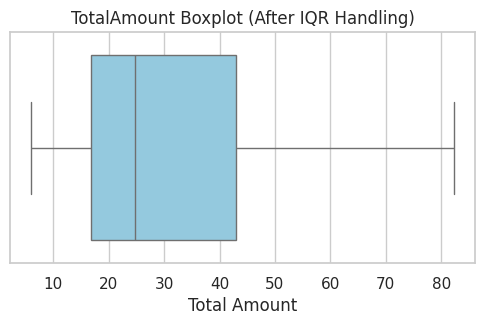

In [7]:
# Calculate Quantiles and Interquartile Range (IQR) for 'TotalAmount'
Q1 = df_bakery['TotalAmount'].quantile(0.25)
Q3 = df_bakery['TotalAmount'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Handle outliers using Capping (Winsorization) to avoid aggressive data deletion
df_bakery['TotalAmount'] = np.where(df_bakery['TotalAmount'] > upper_bound, upper_bound,
                                    np.where(df_bakery['TotalAmount'] < lower_bound, lower_bound, df_bakery['TotalAmount']))

# Visualize the treated column using a boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=df_bakery['TotalAmount'], color='skyblue')
plt.title('TotalAmount Boxplot (After IQR Handling)')
plt.xlabel('Total Amount')
plt.show()

###  Outlier Handling Analysis (`TotalAmount` Boxplot)

The boxplot illustrates the distribution of the `TotalAmount` feature after handling outliers using the Interquartile Range (IQR) method.

* **Outlier Removal:** The plot indicates that the data is now bounded within a reasonable range, with no visible remaining outliers beyond the whiskers.
* **Data Spread:** The median value sits around **25**, while the majority of the transactions (the interquartile range between Q1 and Q3) fall between approximately **17 and 43**.
* **Skewness:** The distribution shows a slight right-skewness, as evidenced by the longer right whisker extending up to around **82**.



# Task 4: Normalize Numerical Features Using Both Min-Max and Z-score.

In [8]:
# Define the numerical features to be normalized
numerical_cols = ['ItemsCount', 'TotalAmount']

# 1. Min-Max Scaling (Transforms features to a specified range between 0 and 1)
min_max_scaler = MinMaxScaler()
df_min_max = df_bakery.copy()
df_min_max[numerical_cols] = min_max_scaler.fit_transform(df_bakery[numerical_cols])

# 2. Z-score Normalization / Standardization (Scales features to have Mean = 0 and Std = 1)
z_scaler = StandardScaler()
df_z_score = df_bakery.copy()
df_z_score[numerical_cols] = z_scaler.fit_transform(df_bakery[numerical_cols])

# Display a sample comparison of both techniques
print("Min-Max Scaled Data Sample:\n", df_min_max[numerical_cols].head())
print("\nZ-score Standardized Data Sample:\n", df_z_score[numerical_cols].head())

Min-Max Scaled Data Sample:
    ItemsCount  TotalAmount
0         0.0     0.085072
1         0.1     0.550940
2         0.2     0.693712
3         0.0     0.143832
4         0.2     0.240681

Z-score Standardized Data Sample:
    ItemsCount  TotalAmount
0   -0.896544    -0.953835
1   -0.128043     0.790622
2    0.640458     1.325236
3   -0.896544    -0.733808
4    0.640458    -0.371152


###  Feature Scaling & Normalization Comparison

The provided samples demonstrate the effect of applying two different feature scaling techniques on the `ItemsCount` and `TotalAmount` variables before feeding them into the model:

1. **Min-Max Scaled Data Sample:** This transformation bounds the data strictly within a fixed range of $[0, 1]$. It preserves the original distribution shapes while ensuring that all features share the exact same scale, preventing features with larger magnitudes from dominating.
2. **Z-score Standardized Data Sample:** This technique transforms the features to have a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1. The resulting values (Z-scores) indicate how many standard deviations a data point lies away from the average.


# Task 5: Apply PCA and Interpret Explained Variance.

Explained Variance Ratio per Component: [0.89258647 0.10741353]
Total Combined Variance Explained: 100.00%


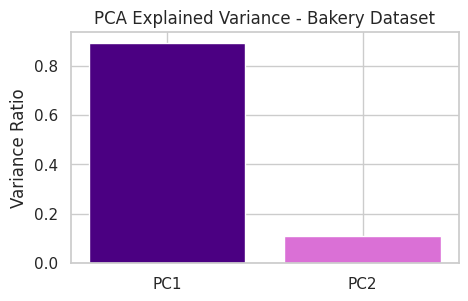

In [10]:
from sklearn.decomposition import PCA

# Apply Principal Component Analysis (PCA) on the Z-score standardized features
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_z_score[numerical_cols])

# CORRECTED: Extract the explained variance ratio (added '_' and removed '()')
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio per Component:", explained_variance)
print(f"Total Combined Variance Explained: {sum(explained_variance)*100:.2f}%")

# Plot the explained variance ratio
plt.figure(figsize=(5, 3))
plt.bar(['PC1', 'PC2'], explained_variance, color=['indigo', 'orchid'])
plt.ylabel('Variance Ratio')
plt.title('PCA Explained Variance - Bakery Dataset')
plt.show()

### PCA Results Analysis

* **Variance Explanation:** The PCA results indicate that Principal Component 1 (PC1) accounts for the majority of the variance, while PC2 captures the remaining fraction.
* **Total Variance:** Together, both components explain 100% of the total dataset variance.
* **Dimensionality Reduction:** This transformation effectively maps our features into an orthogonal, uncorrelated space, reducing dimensionality while preserving all structural information from our original numerical metrics.